[*********************100%***********************]  6 of 6 completed

(1255, 6)
[[ 0.01228752  0.00995465  0.01168861  0.00542667 -0.00745384  0.04706722]
 [-0.0342409  -0.02521178  0.00936603  0.04588671 -0.02074254  0.02519742]
 [ 0.03355402  0.00754857  0.00337299  0.03231153 -0.0088537   0.00781494]
 ...
 [ 0.00131595 -0.00193718 -0.00033725 -0.01276759  0.00375422  0.01185126]
 [-0.00248708  0.00198016 -0.00313653 -0.00101974 -0.00238746  0.00380922]
 [-0.00447761 -0.00738103  0.00019333 -0.00371734 -0.00799905 -0.00538685]]


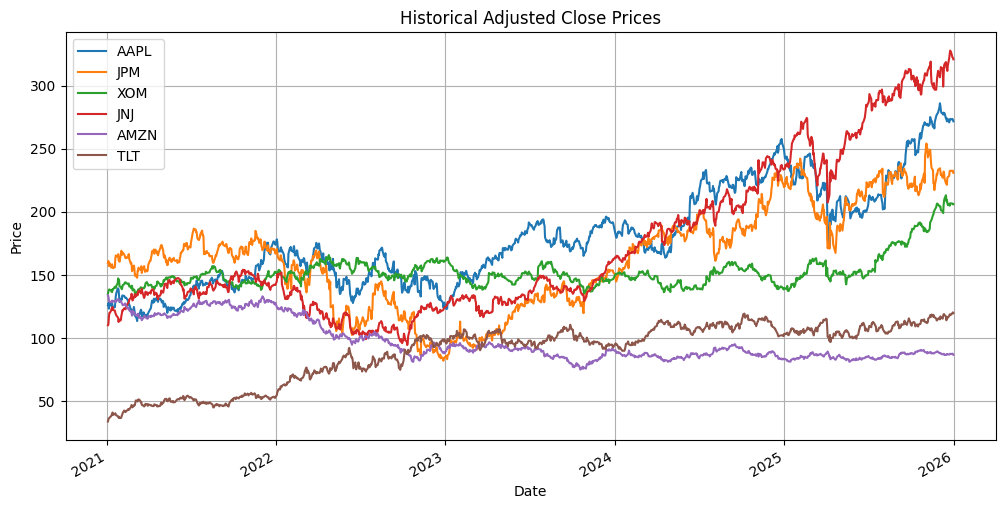

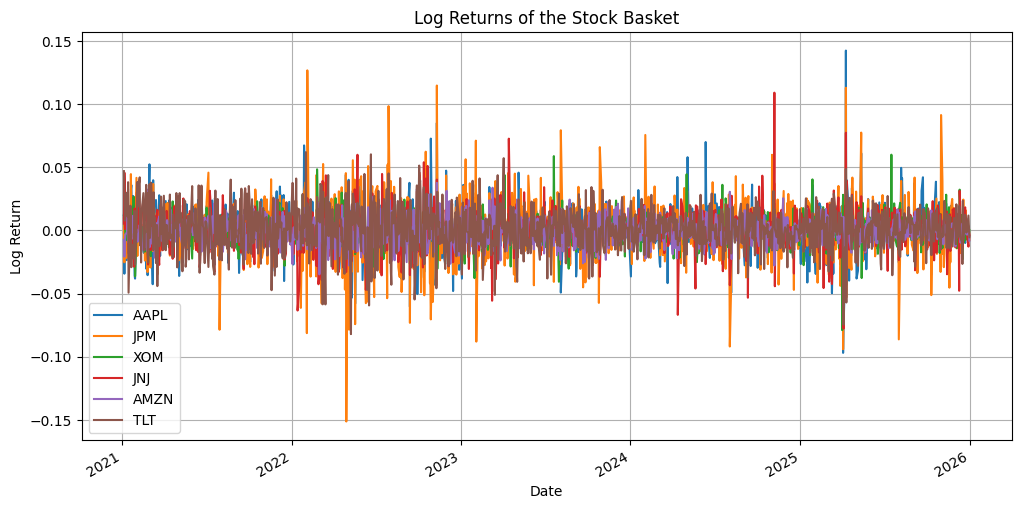

In [ ]:
#Pull price data from a basket of 5-6 stocks from diverse sectors.
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Define the stock tickers for the basket of stocks
tickers = ['AAPL', 'JPM', 'XOM', 'JNJ', 'AMZN', 'TLT']
# Download historical price data for the specified tickers
data = yf.download(tickers, start='2021-01-01', end='2026-01-01')['Close']
# Calculate log returns
log_returns = data.pct_change().apply(lambda x: np.log(1 + x))
#Check the shape of the data, make sure all tickers came through, and compute the returns matrix.
print(log_returns.shape)
# Compute the returns matrix
returns_matrix = log_returns.dropna().values
# Print the returns matrix
print(returns_matrix)
# Plot the price data
data.plot(figsize=(12, 6))
plt.title('Historical Adjusted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(tickers)
plt.grid()
plt.show()
# Plot the log returns
log_returns.plot(figsize=(12, 6))
plt.title('Log Returns of the Stock Basket')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend(tickers)
plt.grid()
plt.show()

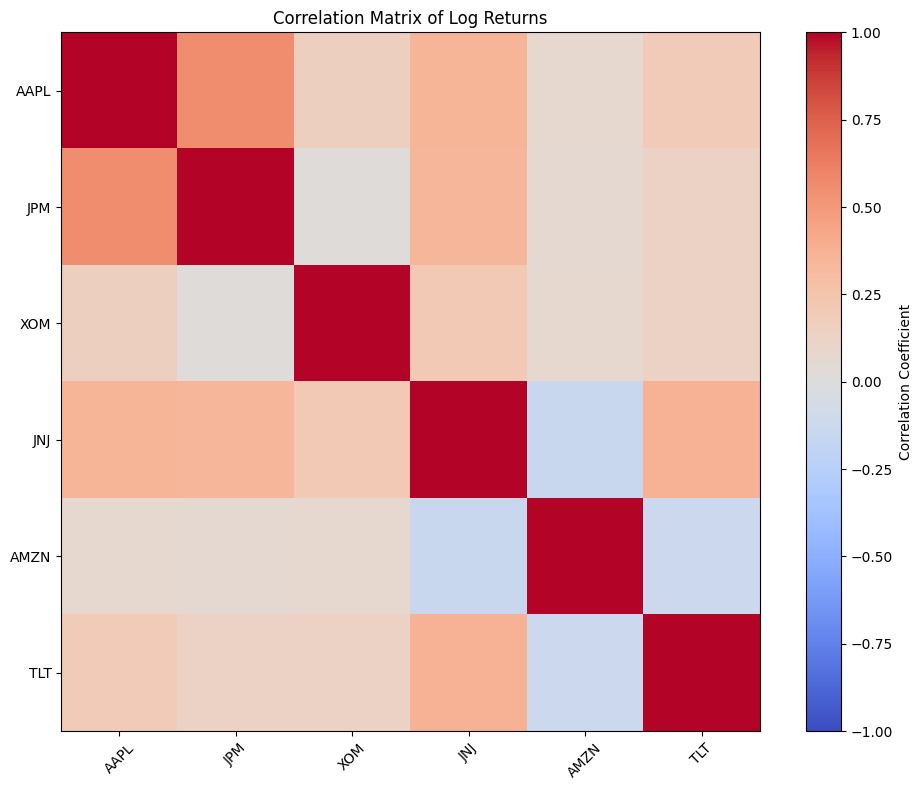

In [5]:
#Compute the correlation matrix and plot it
correlation_matrix = log_returns.corr()
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(tickers)), tickers, rotation=45)
plt.yticks(range(len(tickers)), tickers)
plt.title('Correlation Matrix of Log Returns')
plt.tight_layout()
plt.show()

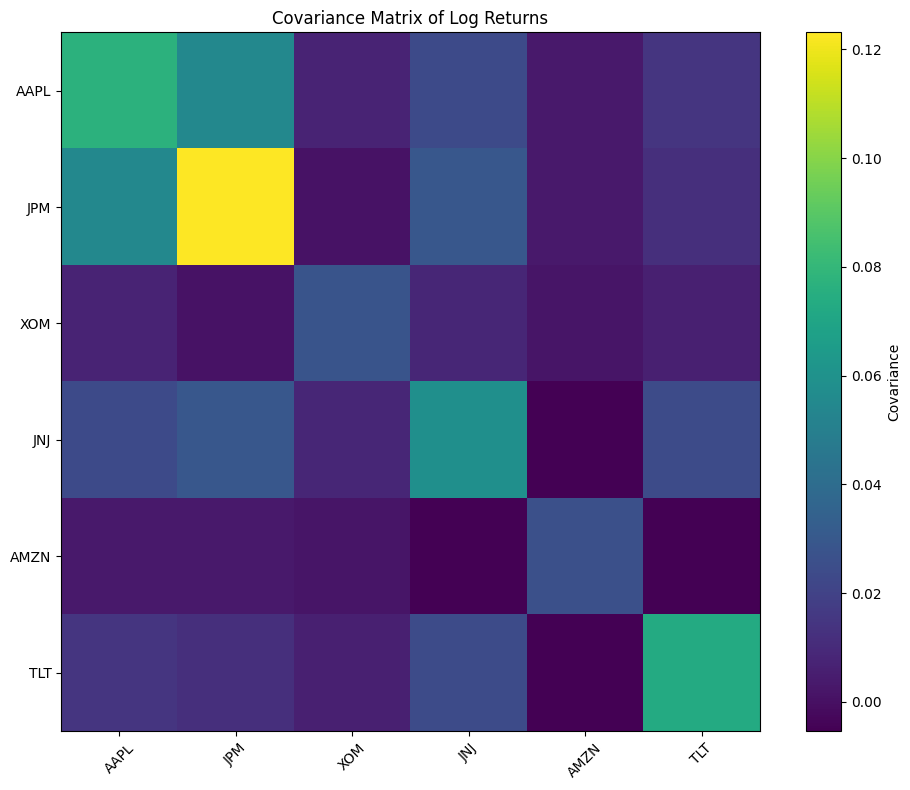

In [6]:
#Compute annualized returns, then compute its covariance matrix, and plot it
# Compute annualized returns
annualized_returns = log_returns.mean() * 252
# Compute covariance matrix
covariance_matrix = log_returns.cov() * 252
# Plot the covariance matrix
plt.figure(figsize=(10, 8))
plt.imshow(covariance_matrix, cmap='viridis')
plt.colorbar(label='Covariance')
plt.xticks(range(len(tickers)), tickers, rotation=45)
plt.yticks(range(len(tickers)), tickers)
plt.title('Covariance Matrix of Log Returns')
plt.tight_layout()
plt.show()


Build optimizer: needs:
Annualized mean returns for each ticker
The annualized covariance matrix
scipy.optimize.minimize to find the weights that maximize the Sharpe ratio


In [32]:
mean_returns = log_returns.mean() * 252
num_assets = len(tickers)
initial_weights = np.array([1/num_assets] * num_assets)  # [0.167, 0.167, 0.167, 0.167, 0.167, 0.167]
cov_matrix = log_returns.cov() * 252
# Build the mean-variance optimization model
from scipy.optimize import minimize
def objective_function(weights, mean_returns, cov_matrix, risk_free_rate):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights, np.dot(cov_matrix, weights)))
    negative_sharpe = -(portfolio_return - risk_free_rate) / portfolio_volatility
    return negative_sharpe
# Constraints: weights sum to 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.5, 0.3) for _ in range(num_assets))
# Initial guess: equal weights
initial_weights = np.array([1/num_assets] * num_assets)
# Optimize the portfolio
import os
os.chdir(os.path.expanduser('~/market-workbench'))
from core.data_fetcher import get_risk_free_rate
risk_free_rate = get_risk_free_rate()
optimized_result = minimize(objective_function, initial_weights, args=(mean_returns, cov_matrix, risk_free_rate), method='SLSQP', bounds=bounds, constraints=constraints)
optimized_weights = optimized_result.x
print("Optimized Portfolio Weights:")
for ticker, weight in zip(tickers, optimized_weights):
    print(f"{ticker}: {weight:.4f}")

/Users/nikoswoozy/market-workbench/venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.stlouisfed.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ValueError: An upper bound is less than the corresponding lower bound.

In [19]:
# Optimized portfolio stats
opt_return = np.dot(optimized_weights, mean_returns)
opt_vol = np.sqrt(np.dot(optimized_weights, np.dot(cov_matrix, optimized_weights)))
opt_sharpe = (opt_return - risk_free_rate) / opt_vol

# Equal weight benchmark
eq_weights = np.array([1/num_assets] * num_assets)
eq_return = np.dot(eq_weights, mean_returns)
eq_vol = np.sqrt(np.dot(eq_weights, np.dot(cov_matrix, eq_weights)))
eq_sharpe = (eq_return - risk_free_rate) / eq_vol

print(f"Optimized — Return: {opt_return:.4f}, Vol: {opt_vol:.4f}, Sharpe: {opt_sharpe:.4f}")
print(f"Equal Wt  — Return: {eq_return:.4f}, Vol: {eq_vol:.4f}, Sharpe: {eq_sharpe:.4f}")

Optimized — Return: 0.1772, Vol: 0.1588, Sharpe: 0.8527
Equal Wt  — Return: 0.1160, Vol: 0.1436, Sharpe: 0.5163


In [20]:
# Split data
train_returns = log_returns['2021':'2023']
test_returns = log_returns['2024':'2025']

# Optimize on training data only
train_mean = train_returns.mean() * 252
train_cov = train_returns.cov() * 252

train_result = minimize(objective_function, initial_weights, 
                        args=(train_mean, train_cov, risk_free_rate),
                        method='SLSQP', bounds=bounds, constraints=constraints)
train_weights = train_result.x

# Evaluate those weights on test data
test_mean = test_returns.mean() * 252
test_cov = test_returns.cov() * 252

oos_return = np.dot(train_weights, test_mean)
oos_vol = np.sqrt(np.dot(train_weights, np.dot(test_cov, train_weights)))
oos_sharpe = (oos_return - risk_free_rate) / oos_vol

print(f"In-sample Sharpe (2021-2023):  {-(train_result.fun):.4f}")
print(f"Out-of-sample Sharpe (2024-2025): {oos_sharpe:.4f}")

In-sample Sharpe (2021-2023):  0.7028
Out-of-sample Sharpe (2024-2025): 1.1107


Value at Risk (0.5 hrs):

Parametric VaR (assumes normality): z_score × portfolio_vol × portfolio_value
Historical VaR (actual return distribution): sort returns, take 5th percentile
Show both side by side
Plot return distribution with normal overlay → visually demonstrate fat tails
Report excess kurtosis

Parametric VaR at 95% confidence: 0.0157
Historical VaR at 95% confidence: 0.0157
Excess Kurtosis of Portfolio Returns: 4.5284


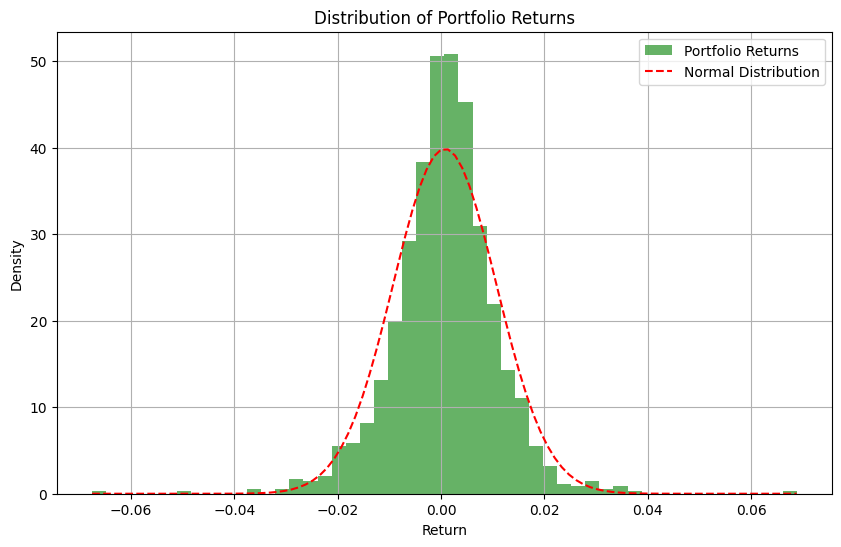

Parametric VaR: 0.015749
Historical VaR: 0.015718
5th percentile of returns: -0.015718
Mean: 0.000703
Std: 0.010002
Parametric VaR 99%: 0.022565
Historical VaR 99%: 0.025938


In [27]:
#Parametric VaR 
from scipy.stats import norm
def parametric_var(weights, daily_mean, daily_cov, confidence_level=0.95):
    portfolio_mean = np.dot(weights, daily_mean)
    portfolio_vol = np.sqrt(np.dot(weights, np.dot(daily_cov, weights)))
    z_score = norm.ppf(1 - confidence_level)
    var = -(portfolio_mean + z_score * portfolio_vol)
    return var

daily_mean = log_returns.mean()
daily_cov = log_returns.cov()
var_value = parametric_var(optimized_weights, daily_mean, daily_cov)
confidence_level = 0.95
print(f"Parametric VaR at {confidence_level*100:.0f}% confidence: {var_value:.4f}")
#Historical VaR
def historical_var(weights, returns, confidence_level=0.95):
    portfolio_returns = returns.dot(weights)
    var = -np.percentile(portfolio_returns, (1 - confidence_level) * 100)
    return var
hist_var_value = historical_var(optimized_weights, log_returns.dropna(), confidence_level)
print(f"Historical VaR at {confidence_level*100:.0f}% confidence: {hist_var_value:.4f}")
# Show side by side
var_df = pd.DataFrame({
    'Method': ['Parametric VaR', 'Historical VaR'],
    'VaR Value': [var_value, hist_var_value]
})
# Report excess kurtosis
from scipy.stats import kurtosis
portfolio_returns = log_returns.dropna().dot(optimized_weights)
excess_kurtosis = kurtosis(portfolio_returns, fisher=True)
print(f"Excess Kurtosis of Portfolio Returns: {excess_kurtosis:.4f}")
plt.figure(figsize=(10, 6))
plt.hist(portfolio_returns, bins=50, density=True, alpha=0.6, color='g', label='Portfolio Returns')
# Overlay normal distribution
x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
pdf = norm.pdf(x, portfolio_returns.mean(), portfolio_returns.std())
plt.plot(x, pdf, 'r--', label='Normal Distribution')
plt.title('Distribution of Portfolio Returns')
plt.xlabel('Return')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

print(f"Parametric VaR: {var_value:.6f}")
print(f"Historical VaR: {hist_var_value:.6f}")
portfolio_returns = log_returns.dropna().dot(optimized_weights)
print(f"5th percentile of returns: {np.percentile(portfolio_returns, 5):.6f}")
print(f"Mean: {portfolio_returns.mean():.6f}")
print(f"Std: {portfolio_returns.std():.6f}")

print(f"Parametric VaR 99%: {parametric_var(optimized_weights, daily_mean, daily_cov, 0.99):.6f}")
print(f"Historical VaR 99%: {historical_var(optimized_weights, log_returns.dropna(), 0.99):.6f}")

Bootstrapped efficient frontier: Loop 1000x, resample return history with replacement, reurn optimizer on resampled data, store curve
Helps us understand estimation error visually. 

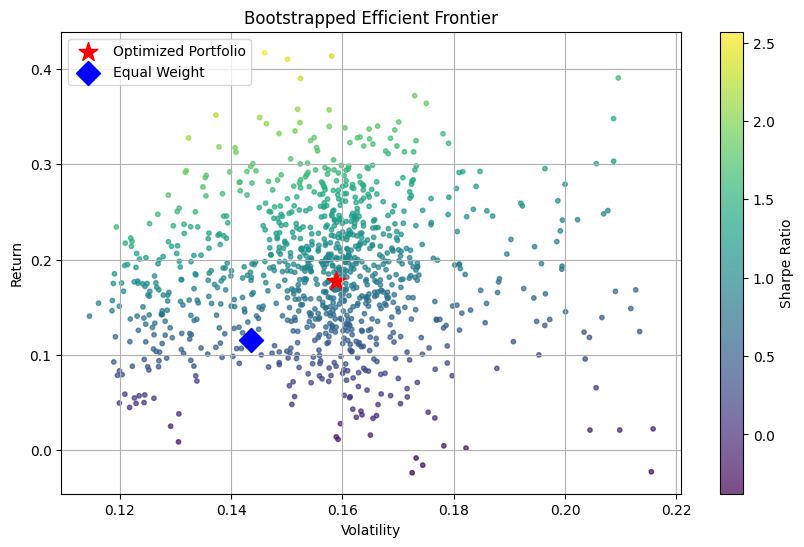

In [30]:
# Bootstrapped efficent frontier
def bootstrap_efficient_frontier(returns, num_portfolios=1000, confidence_level=0.95):
    num_assets = returns.shape[1]
    bootstrap_weights = []
    bootstrap_returns = []
    bootstrap_vols = []
    for _ in range(num_portfolios):
        # Resample returns with replacement
        boot_returns = returns.sample(frac=1, replace=True)
        boot_mean = boot_returns.mean() * 252
        boot_cov = boot_returns.cov() * 252
        # Optimize portfolio on bootstrapped data
        result = minimize(objective_function, initial_weights, 
                          args=(boot_mean, boot_cov, risk_free_rate),
                          method='SLSQP', bounds=bounds, constraints=constraints)
        weights = result.x
        bootstrap_weights.append(weights)
        bootstrap_returns.append(np.dot(weights, boot_mean))
        bootstrap_vols.append(np.sqrt(np.dot(weights, np.dot(boot_cov, weights))))
    return np.array(bootstrap_weights), np.array(bootstrap_returns), np.array(bootstrap_vols)
bootstrap_weights, bootstrap_returns, bootstrap_vols = bootstrap_efficient_frontier(log_returns.dropna())
plt.figure(figsize=(10, 6))
plt.scatter(bootstrap_vols, bootstrap_returns, c=(bootstrap_returns - risk_free_rate) / bootstrap_vols, cmap='viridis', marker='o', s=10, alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(opt_vol, opt_return, color='red', marker='*', s=200, label='Optimized Portfolio')
plt.scatter(eq_vol, eq_return, color='blue', marker='D', s=150, label='Equal Weight')
plt.title('Bootstrapped Efficient Frontier')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()
plt.grid()
plt.show()